In [1]:
import numpy as np
import pandas as pd

from fronts_dataloader.fronts_dataset import FrontDataSource, RawFronts

STORE = ("s3://dbof/globals_for_cutouts/v2_2_03/Fronts/V5/SURF/fronts.zarr")

#: Nautilus, not AWS, so the endpoint has to be given explicitly.
S3_ENDPOINT = "https://s3-west.nrp-nautilus.io"

source = FrontDataSource(STORE, storage_options={"endpoint_url": S3_ENDPOINT})
print(f"{len(source.dates)} snapshots")
print(source.store.status().to_string(index=False))

100 snapshots
           date find group colocate
20111204_000000 done  done     done
20111206_180000 done  done     done
20111209_190000 done  done     done
20111212_110000 done  done     done
20111216_030000 done  done     done
20111218_170000 done  done     done
20111222_080000 done  done     done
20111225_150000 done  done     done
20111229_160000 done  done     done
20120104_110000 done  done     done
20120107_090000 done  done     done
20120111_190000 done  done     done
20120113_210000 done  done     done
20120117_180000 done  done     done
20120122_130000 done  done     done
20120125_050000 done  done     done
20120128_090000 done  done     done
20120131_140000 done  done     done
20120204_040000 done  done     done
20120208_230000 done  done     done
20120210_040000 done  done     done
20120215_140000 done  done     done
20120218_140000 done  done     done
20120219_180000 done  done     done
20120224_150000 done  done     done
20120229_180000 done  done     done
20120303_05000

In [7]:
FEATURES_RAW = ["orientation","oceTAUX", "oceTAUY"]

dates=["20120923_080000"]

raw = RawFronts.load(source, features=FEATURES_RAW, dates=dates)
print(f"{len(raw):,} fronts over {len(source.dates)} snapshots")
print(raw.table.groupby("date").size().rename("fronts").to_string())

KeyboardInterrupt: 

In [38]:
fronts_ds = raw.select(FEATURES_RAW, ihs_channels=False, log_channels=False, stats=["mean"], scaling=None)

In [39]:
df = fronts_ds.to_frame()
df

,date,label,name,time,orientation,oceTAUX_mean,oceTAUY_mean
0,20120923_080000,1893,20120923TT080000_74.5S_165.6W,2012-09-23T08:00:00,-65.944580,0.000691,0.015288
1,20120923_080000,1894,20120923TT080000_74.2S_158.3W,2012-09-23T08:00:00,-28.740908,-0.007688,0.015312
2,20120923_080000,1895,20120923TT080000_74.9S_172.9E,2012-09-23T08:00:00,-88.725861,0.025216,0.033004
3,20120923_080000,1896,20120923TT080000_74.5S_168.2W,2012-09-23T08:00:00,31.924421,-0.000829,0.051702
4,20120923_080000,1897,20120923TT080000_74.5S_165.2W,2012-09-23T08:00:00,-58.109951,-0.000763,0.026674
...,...,...,...,...,...,...,...
113750,20120923_080000,113043,20120923TT080000_71.3N_14.7E,2012-09-23T08:00:00,0.116734,0.021246,-0.007709
113751,20120923_080000,113044,20120923TT080000_70.0N_29.6E,2012-09-23T08:00:00,-62.856697,-0.009801,-0.000634
113752,20120923_080000,113045,20120923TT080000_70.9N_174.3E,2012-09-23T08:00:00,-5.593033,-0.027282,0.025675
113753,20120923_080000,113046,20120923TT080000_70.2N_13.5W,2012-09-23T08:00:00,-42.514584,-0.082258,-0.061094


In [40]:
windx = df["oceTAUX_mean"]
windy = df["oceTAUY_mean"]

_wind_dir  = np.degrees(np.arctan2(windx, windy))

In [41]:
_wind_dir # -180 to 180 degrees from +y or north direction

0           2.589204
1         -26.660496
2          37.380795
3          -0.919159
4          -1.638011
             ...    
113750    109.942917
113751    -93.703331
113752    -46.737537
113753   -126.601608
113754    139.717682
Length: 113755, dtype: float32

In [42]:
print(min(_wind_dir), max(_wind_dir))

-179.9979248046875 179.9955291748047


In [43]:
print(df["orientation"].min(), df["orientation"].max())

-90.0 90.0


In [46]:
angle = np.abs(((_wind_dir - df["orientation"] + 90) % 180) - 90)

In [47]:
angle

0         68.533783
1          2.080414
2         53.893341
3         32.843582
4         56.471939
            ...    
113750    70.173828
113751    30.846634
113752    41.144505
113753    84.087021
113754    15.579041
Length: 113755, dtype: float32

n=113,755  mean=44.46  median=43.98


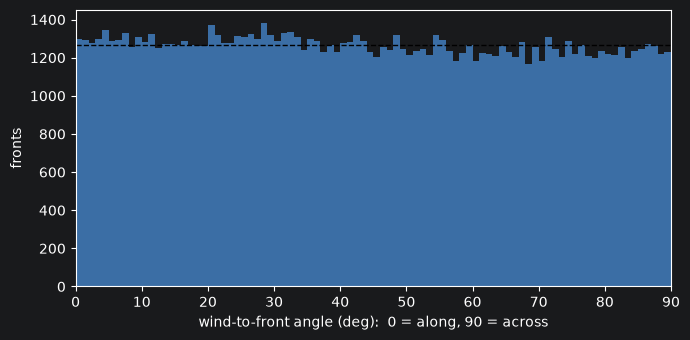

In [48]:
import matplotlib.pyplot as plt
#
# t  = raw.table
# o  = t["orientation"].to_numpy()
# tx = t["oceTAUX_mean"].to_numpy()
# ty = t["oceTAUY_mean"].to_numpy()

angle = angle[np.isfinite(angle)]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(angle, bins=90, range=(0, 90), color="#3b6ea5")
# Flat is what an unrelated wind and front would give; departures are the signal.
ax.axhline(angle.size / 90, ls="--", c="k", lw=1)
ax.set(xlabel="wind-to-front angle (deg):  0 = along, 90 = across",
       ylabel="fronts", xlim=(0, 90))
fig.tight_layout()

print(f"n={angle.size:,}  mean={angle.mean():.2f}  median={np.median(angle):.2f}")

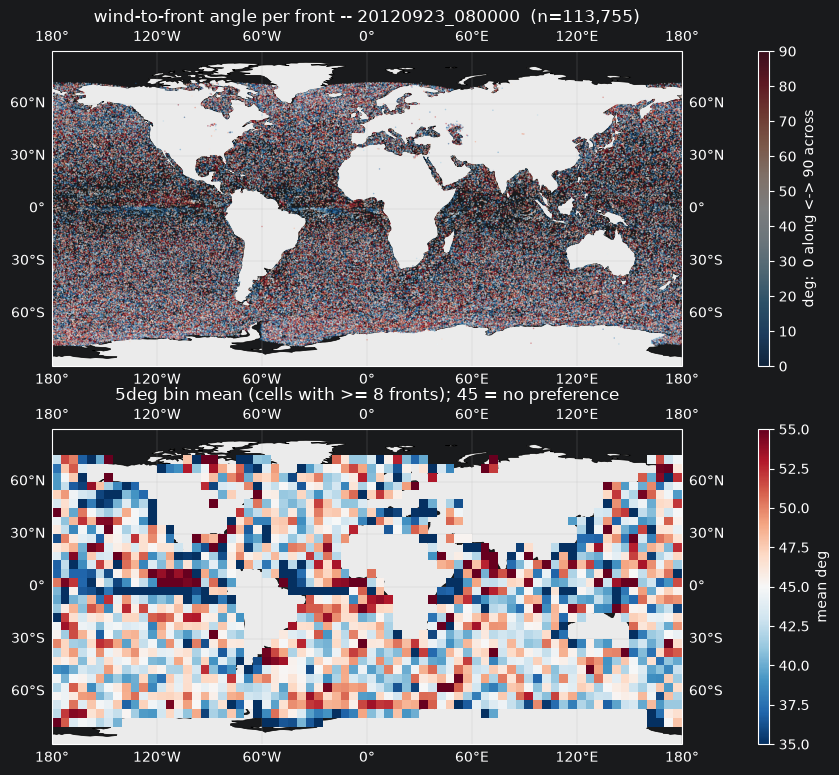

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from visualization.visualization import (_PROJ, _global_ax, _side_colorbar,
                                         _reserve_side_colorbars)

t = raw.table[raw.table["date"] == dates[0]]        # one snapshot

lat = t["centroid_lat"].to_numpy()
lon = t["centroid_lon"].to_numpy()
# # orientation and arctan2(east, north) share the from-north zero, so they
# # subtract directly; the fold takes the result to the acute angle in [0, 90].
# wind = np.degrees(np.arctan2(t["oceTAUX_mean"].to_numpy(),
#                              t["oceTAUY_mean"].to_numpy()))
# angle = np.abs(((wind - t["orientation"].to_numpy() + 90) % 180) - 90)

ok = np.isfinite(angle) & np.isfinite(lat) & np.isfinite(lon)
lat, lon, angle = lat[ok], lon[ok], angle[ok]

fig = plt.figure(figsize=(11, 9))
_reserve_side_colorbars(fig, 1)

# One dot per front.  The marginal is near-uniform, so this mostly shows
# coverage; regional signal needs the binned panel below.
ax = _global_ax(fig, (2, 1, 1), (-180, 180, -90, 90), True, draw_labels=True)
sc = ax.scatter(lon, lat, c=angle, s=1.2, alpha=0.45, linewidths=0,
                cmap="RdBu_r", vmin=0, vmax=90, transform=_PROJ, zorder=2)
ax.set_title(f"wind-to-front angle per front -- {dates[0]}  (n={angle.size:,})")
_side_colorbar(fig, ax, sc, "deg:  0 along <-> 90 across")

# Bin means.  A few-percent modulation is invisible per front but survives
# averaging; cells under MIN_N are left blank rather than shown as noise.
BIN, MIN_N = 5.0, 8
xe = np.arange(-180, 180 + BIN, BIN)
ye = np.arange(-90, 90 + BIN, BIN)
tot = np.histogram2d(lon, lat, bins=[xe, ye], weights=angle)[0]
cnt = np.histogram2d(lon, lat, bins=[xe, ye])[0]
mean = np.where(cnt >= MIN_N, tot / np.maximum(cnt, 1), np.nan)

ax2 = _global_ax(fig, (2, 1, 2), (-180, 180, -90, 90), True, draw_labels=True)
pm = ax2.pcolormesh(xe, ye, mean.T, cmap="RdBu_r", vmin=35, vmax=55,
                    transform=_PROJ, zorder=2)
ax2.set_title(f"{BIN:.0f}deg bin mean (cells with >= {MIN_N} fronts); 45 = no preference")
_side_colorbar(fig, ax2, pm, "mean deg")